In [32]:
import pandas as pd

In [33]:
df =  pd.read_csv("/content/preprocessing_practice_dataset.csv")

In [34]:
df.head()

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes
2,1003,35.0,Female,HR,NaN,19,119297.0,1,Kochi,Yes
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         100 non-null    int64  
 1   Age                 90 non-null     float64
 2   Gender              100 non-null    object 
 3   Department          90 non-null     object 
 4   Education           90 non-null     object 
 5   Experience_Years    100 non-null    int64  
 6   Monthly_Salary      90 non-null     float64
 7   Performance_Rating  100 non-null    int64  
 8   City                90 non-null     object 
 9   Attrition           100 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 7.9+ KB


In [36]:
df.describe()

,Employee_ID,Age,Experience_Years,Monthly_Salary,Performance_Rating
count,100.000000,90.000000,100.000000,90.000000,100.000000
mean,1050.500000,39.866667,9.360000,75111.988889,3.230000
std,29.011492,11.015005,6.210971,28068.924984,1.476106
min,1001.000000,21.000000,0.000000,25412.000000,1.000000
25%,1025.750000,29.250000,4.000000,50536.250000,2.000000
50%,1050.500000,41.000000,10.000000,72715.500000,4.000000
75%,1075.250000,48.000000,15.000000,99079.000000,5.000000
max,1100.000000,59.000000,19.000000,119297.000000,5.000000


In [37]:
df.isnull().sum()

,0
Employee_ID,0
Age,10
Gender,0
Department,10
Education,10
Experience_Years,0
Monthly_Salary,10
Performance_Rating,0
City,10
Attrition,0


In [38]:
df['age_mean'] = df['Age'].fillna(df['Age'].mean())

In [39]:
df['dep_mode'] = df['Department'].fillna(df['Department'].mode()[0])
df['city'] = df['City'].fillna(df['City'].mode()[0])
df['education'] = df['Education'].fillna(df['Education'].mode()[0])
df['salary'] = df['Monthly_Salary'].fillna(df['Monthly_Salary'].mean())

/tmp/ipykernel_1638/46199485.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='dep_mode',y='age_mean',palette='pastel')


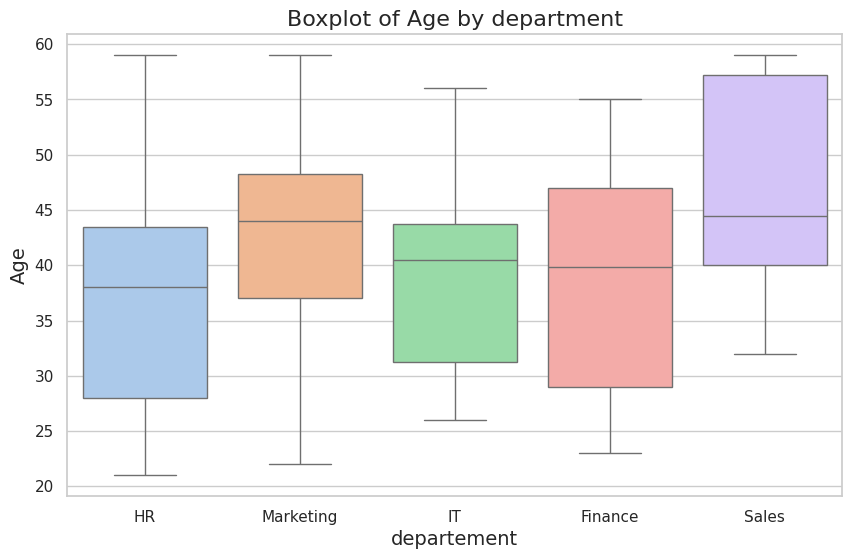

In [40]:
sns.set(style='whitegrid')

plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='dep_mode',y='age_mean',palette='pastel')

plt.title('Boxplot of Age by department',fontsize=16)
plt.xlabel('departement',fontsize=14)
plt.ylabel('Age',fontsize=14)
plt.show()

/tmp/ipykernel_1638/1321001426.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dep_mode', palette='viridis')


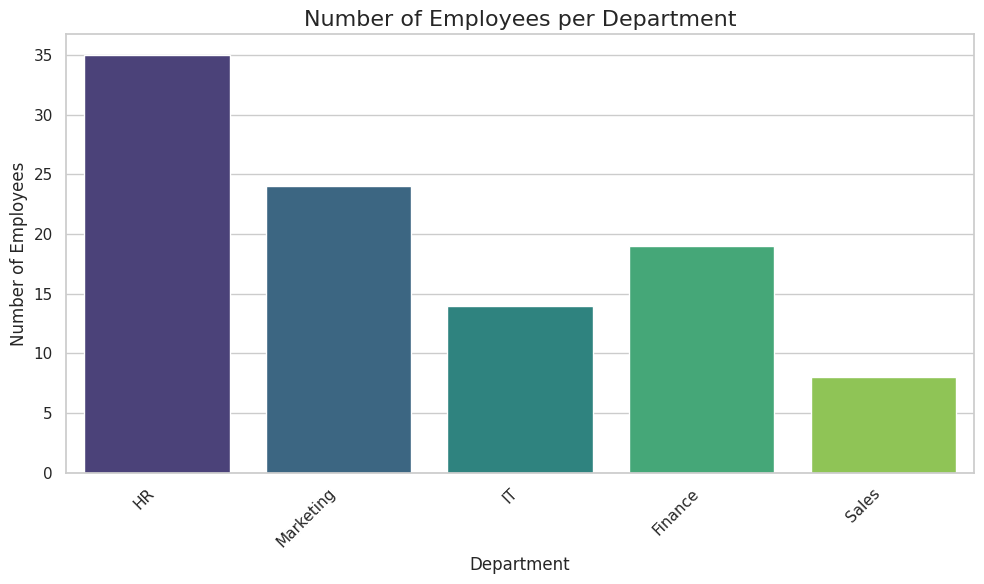

In [112]:



sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='dep_mode', palette='viridis')
plt.title('Number of Employees per Department', fontsize=16)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

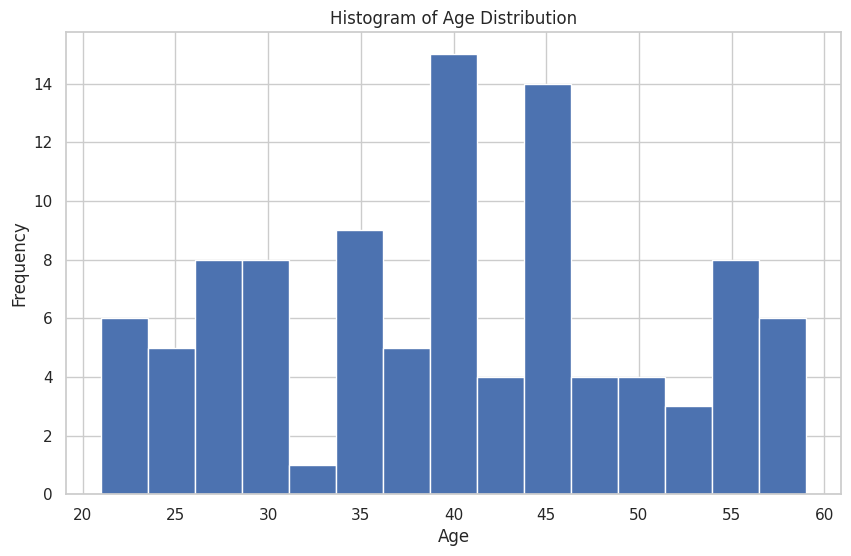

In [113]:

plt.figure(figsize=(10, 6))
plt.hist(x=df['age_mean'].dropna(), bins=15)
plt.title('Histogram of Age Distribution', fontsize=12)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

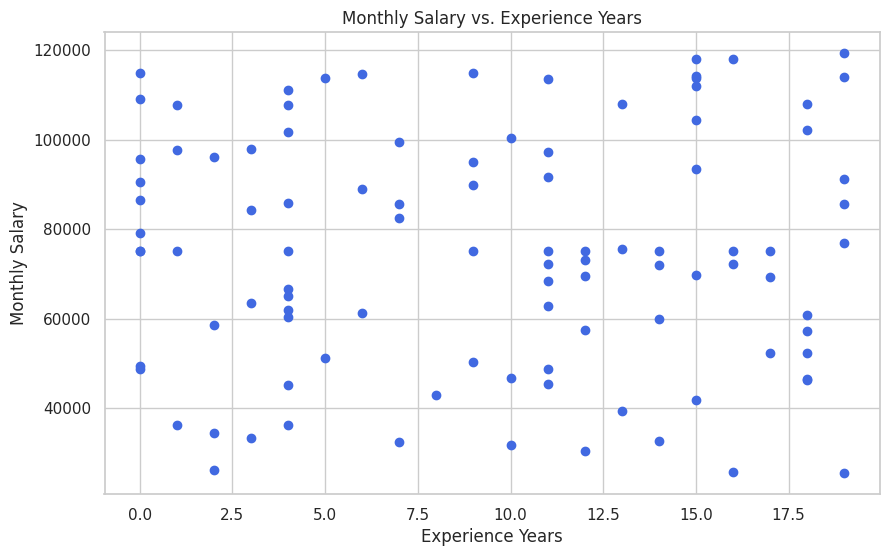

In [114]:
plt.figure(figsize=(10, 6))
plt.scatter(x=df['Experience_Years'], y=df['salary'], color='royalblue')
plt.title('Monthly Salary vs. Experience Years')
plt.xlabel('Experience Years')
plt.ylabel('Monthly Salary')
plt.show()

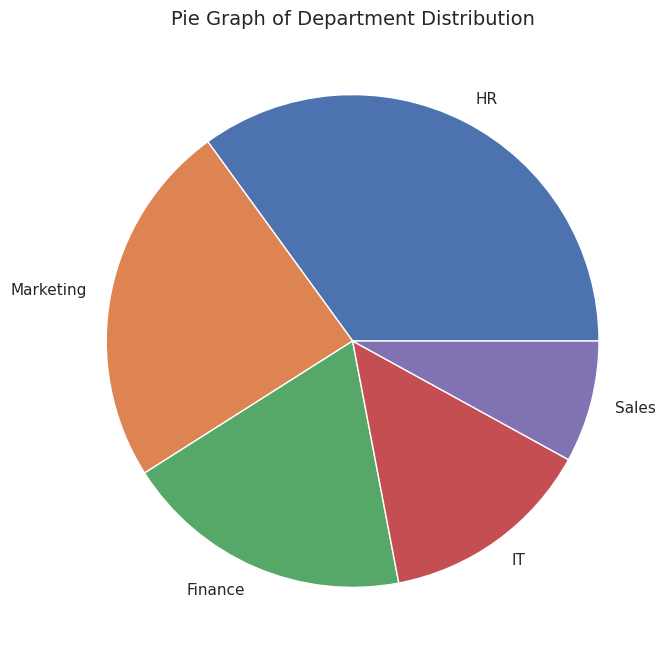

In [116]:
sns.set_theme(style="whitegrid")
dept_counts = df['dep_mode'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(x=dept_counts.values,
        labels=dept_counts.index)
plt.title('Pie Graph of Department Distribution', fontsize=14)
plt.show()

In [88]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [97]:
encoded_data = df.copy()

In [98]:
encoded_data

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition,age_mean,dep_mode,city,education,salary
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No,59.0,HR,Calicut,Masters,52350.0
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes,49.0,Marketing,Chennai,Bachelors,118008.0
2,1003,35.0,Female,HR,NaN,19,119297.0,1,Kochi,Yes,35.0,HR,Kochi,Masters,119297.0
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes,28.0,HR,Trivandrum,PhD,50351.0
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes,41.0,IT,Trivandrum,Bachelors,113668.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,54.0,Female,HR,Masters,11,48625.0,5,Chennai,Yes,54.0,HR,Chennai,Masters,48625.0
96,1097,53.0,Male,Marketing,Masters,13,107873.0,5,Trivandrum,Yes,53.0,Marketing,Trivandrum,Masters,107873.0
97,1098,43.0,Male,NaN,PhD,1,97592.0,3,Chennai,No,43.0,HR,Chennai,PhD,97592.0
98,1099,44.0,Female,Marketing,PhD,18,102052.0,5,Calicut,Yes,44.0,Marketing,Calicut,PhD,102052.0


In [99]:
label_encoder = LabelEncoder()
encoded_data['gender_label'] = label_encoder.fit_transform(encoded_data['Gender'])
encoded_data['attrition'] = label_encoder.fit_transform(encoded_data['Attrition'])




In [100]:
one_hot_encoded = pd.get_dummies(encoded_data['dep_mode'],prefix='dep_mode')
encoded_data = pd.concat([encoded_data,one_hot_encoded],axis=1)

In [101]:
one_hot_encoded = pd.get_dummies(encoded_data['city'],prefix='city')
encoded_data = pd.concat([encoded_data,one_hot_encoded],axis=1)

In [102]:
one_hot_encoded = pd.get_dummies(encoded_data['education'],prefix='education')
encoded_data = pd.concat([encoded_data,one_hot_encoded],axis=1)

In [103]:
numerical_columns = ['Age','Department','Education','Monthly_Salary']

In [105]:
encoded_data = encoded_data.drop(columns=numerical_columns)

In [106]:
print(encoded_data)

    Employee_ID  Gender  Experience_Years  Performance_Rating        City  \
0          1001    Male                18                   5     Calicut   
1          1002  Female                16                   2     Chennai   
2          1003  Female                19                   1       Kochi   
3          1004  Female                 9                   2  Trivandrum   
4          1005    Male                 5                   3  Trivandrum   
..          ...     ...               ...                 ...         ...   
95         1096  Female                11                   5     Chennai   
96         1097    Male                13                   5  Trivandrum   
97         1098    Male                 1                   3     Chennai   
98         1099  Female                18                   5     Calicut   
99         1100  Female                17                   2     Calicut   

   Attrition  age_mean   dep_mode        city  education  ...  \
0         

In [107]:
from sklearn.preprocessing import MinMaxScaler,MaxAbsScaler,StandardScaler,RobustScaler

In [108]:
minmax_scalar = MinMaxScaler()
standard_scalar = StandardScaler()

In [109]:
encoded_data['Age_MinMax'] = minmax_scalar.fit_transform(encoded_data[['age_mean']])
encoded_data['sal_MinMax'] = minmax_scalar.fit_transform(encoded_data[['salary']])

encoded_data['Age_standard'] = standard_scalar.fit_transform(encoded_data[['age_mean']])
encoded_data['salary_standard'] = standard_scalar.fit_transform(encoded_data[['salary']])

In [110]:
encoded_data

,Employee_ID,Gender,Experience_Years,Performance_Rating,City,Attrition,age_mean,dep_mode,city,education,...,city_Chennai,city_Kochi,city_Trivandrum,education_Bachelors,education_Masters,education_PhD,Age_MinMax,sal_MinMax,Age_standard,salary_standard
0,1001,Male,18,5,Calicut,No,59.0,HR,Calicut,Masters,...,False,False,False,False,True,False,1.000000,0.286925,1.841242,-0.859586
1,1002,Female,16,2,Chennai,Yes,49.0,Marketing,Chennai,Bachelors,...,True,False,False,True,False,False,0.736842,0.986270,0.878921,1.619930
2,1003,Female,19,1,Kochi,Yes,35.0,HR,Kochi,Masters,...,False,True,False,False,True,False,0.368421,1.000000,-0.468330,1.668607
3,1004,Female,9,2,Trivandrum,Yes,28.0,HR,Trivandrum,PhD,...,False,False,True,False,False,True,0.184211,0.265633,-1.141955,-0.935077
4,1005,Male,5,3,Trivandrum,Yes,41.0,IT,Trivandrum,Bachelors,...,False,False,True,True,False,False,0.526316,0.940044,0.109063,1.456033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,Female,11,5,Chennai,Yes,54.0,HR,Chennai,Masters,...,True,False,False,False,True,False,0.868421,0.247249,1.360081,-1.000257
96,1097,Male,13,5,Trivandrum,Yes,53.0,Marketing,Trivandrum,Masters,...,False,False,True,False,True,False,0.842105,0.878319,1.263849,1.237190
97,1098,Male,1,3,Chennai,No,43.0,HR,Chennai,PhD,...,True,False,False,False,False,True,0.578947,0.768813,0.301527,0.848938
98,1099,Female,18,5,Calicut,Yes,44.0,Marketing,Calicut,PhD,...,False,False,False,False,False,True,0.605263,0.816318,0.397760,1.017365
